In [31]:
import os
from dotenv import load_dotenv

load_dotenv()
token = os.getenv('KAGGLE_API_TOKEN')

# Part 1: Data import and analysis
## a) Import data


In [32]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)


from kaggle.api.kaggle_api_extended import KaggleApi

# Load environment variables
load_dotenv()

# Authenticate with Kaggle using the token from .env
api = KaggleApi()
api.authenticate()

# Download the dataset with force option to re-download if corrupted
dataset_path = '/home/linux-mint-cb303/Desktop/UET/FootballPredictionsAFC/data'
api.dataset_download_files('martj42/international-football-results-from-1872-to-2017', path=dataset_path, unzip=True, force=True)

print(f"Dataset downloaded to: {dataset_path}")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Dataset URL: https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017
Dataset downloaded to: /home/linux-mint-cb303/Desktop/UET/FootballPredictionsAFC/data


In [33]:
from pathlib import Path
import re
import numpy as np
import pandas as pd


def team_name_to_slug(team_name: str) -> str:
    """Convert team names to slug format used by the country-year scraper output."""
    alias = {
        "China PR": "China",
        "Saudi Arabia": "Saudi_Arabia",
        "United Arab Emirates": "United_Arab_Emirates",
        "South Korea": "South_Korea",
        "North Korea": "North_Korea",
        "Hong Kong": "Hong_Kong",
        "Northern Mariana Islands": "Northern_Mariana_Islands",
        "Timor-Leste": "East_Timor",
    }
    if team_name in alias:
        return alias[team_name]
    return str(team_name).replace("-", "_").replace(" ", "_")


def parse_height_to_m(value):
    """Convert height like '1.77m' or '177 cm' to meters float."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if not text:
        return np.nan

    m_match = re.search(r"(\d+(?:\.\d+)?)\s*m", text)
    if m_match:
        return float(m_match.group(1))

    cm_match = re.search(r"(\d+(?:\.\d+)?)\s*cm", text)
    if cm_match:
        return float(cm_match.group(1)) / 100.0

    try:
        numeric = float(text)
        return numeric if numeric < 3 else numeric / 100.0
    except ValueError:
        return np.nan


candidate_paths = [
    Path("downloaded_files/scrape_exports/afc_country_year_data.csv"),
    Path("../downloaded_files/scrape_exports/afc_country_year_data.csv"),
]
country_year_stats_path = next((p for p in candidate_paths if p.exists()), None)
if country_year_stats_path is None:
    raise FileNotFoundError(
        "afc_country_year_data.csv not found. Run/export scraper notebook first."
    )

country_year_stats_df = pd.read_csv(country_year_stats_path)
country_year_stats_df["year"] = pd.to_numeric(country_year_stats_df["year"], errors="coerce").astype("Int64")
country_year_stats_df["team_slug"] = country_year_stats_df["country_slug"].astype(str)
country_year_stats_df["team_age"] = pd.to_numeric(country_year_stats_df["average_age"], errors="coerce")
country_year_stats_df["team_height"] = country_year_stats_df["average_height"].apply(parse_height_to_m)

country_year_profile_lookup = country_year_stats_df[["team_slug", "year", "team_age", "team_height"]].drop_duplicates(["team_slug", "year"])

print(f"Loaded country-year profile data: {len(country_year_profile_lookup)} rows from {country_year_stats_path}")

Loaded country-year profile data: 1504 rows from downloaded_files/scrape_exports/afc_country_year_data.csv


In [34]:
df = pd.read_csv(os.path.join(dataset_path, 'results.csv'))

df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49066,2026-01-18,Bolivia,Panama,1,1,Friendly,Tarija,Bolivia,False
49067,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False
49068,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,False
49069,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,False


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49071 entries, 0 to 49070
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49071 non-null  object
 1   home_team   49071 non-null  object
 2   away_team   49071 non-null  object
 3   home_score  49071 non-null  int64 
 4   away_score  49071 non-null  int64 
 5   tournament  49071 non-null  object
 6   city        49071 non-null  object
 7   country     49071 non-null  object
 8   neutral     49071 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.0+ MB


## b) Extract the matches between teams in the AFC Confederation

In [36]:
teams_in_asia = [
    "Afghanistan", "Australia", "Bahrain", "Bangladesh", "Bhutan", 
    "Brunei", "Cambodia", "China PR", "Taiwan", 
    "North Korea", "Guam", "Hong Kong", "India", "Indonesia", "Iran", 
    "Iraq", "Japan", "Jordan", "Kuwait", "Kyrgyzstan", "Laos", 
    "Lebanon", "Macau", "Malaysia", "Maldives", "Mongolia", "Myanmar", 
    "Nepal", "Northern Mariana Islands", "Oman", "Pakistan", "Palestine", 
    "Philippines", "Qatar", "Saudi Arabia", "Singapore", "South Korea", 
    "Sri Lanka", "Syria", "Tajikistan", "Thailand", "Timor-Leste", 
    "Turkmenistan", "United Arab Emirates", "Uzbekistan", "Vietnam", "Yemen"
]



In [37]:
# 1. Convert the date column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# 2. Define the filtering criteria
# We use .isin() to check if both teams are in your list
# and ensure the year is 1995 or greater
afc_matches_since_2000 = df[
    (df['home_team'].isin(teams_in_asia)) & 
    (df['away_team'].isin(teams_in_asia)) & 
    (df['date'].dt.year >= 1995)
]

afc_matches_since_2000

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
20155,1995-02-15,Australia,Japan,2,1,Friendly,Sydney,Australia,False
20161,1995-02-19,China PR,South Korea,0,0,Dynasty Cup,Victoria,Hong Kong,True
20162,1995-02-19,Hong Kong,Japan,0,3,Dynasty Cup,Victoria,Hong Kong,False
20163,1995-02-21,Hong Kong,China PR,0,0,Dynasty Cup,Victoria,Hong Kong,False
20164,1995-02-21,Japan,South Korea,1,1,Dynasty Cup,Victoria,Hong Kong,True
...,...,...,...,...,...,...,...,...,...
49004,2025-12-09,United Arab Emirates,Kuwait,3,1,Arab Cup,Doha,Qatar,True
49008,2025-12-11,Palestine,Saudi Arabia,1,2,Arab Cup,Lusail,Qatar,True
49009,2025-12-12,Jordan,Iraq,1,0,Arab Cup,Al Rayyan,Qatar,True
49012,2025-12-15,Saudi Arabia,Jordan,0,1,Arab Cup,Al Khor,Qatar,True


In [38]:
mask = (
    (afc_matches_since_2000['date'].dt.year >= 2025) &
    (afc_matches_since_2000['date'].dt.month <= 9) &
    (
        (afc_matches_since_2000['home_team'] == 'Malaysia') |
        (afc_matches_since_2000['away_team'] == 'Malaysia')
    )
)

afc_matches_since_2000.loc[mask, 'tournament'] = 'Forfeited'

afc_matches_since_2000[
    (df['date'].dt.year >= 2025) &
    (df['date'].dt.month <= 9) &
    ((afc_matches_since_2000['home_team'] == 'Malaysia') |
     (afc_matches_since_2000['away_team'] == 'Malaysia'))
]


/tmp/ipykernel_1961/268665084.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  afc_matches_since_2000[


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
48204,2025-03-25,Malaysia,Nepal,2,0,Forfeited,Johor,Malaysia,False
48381,2025-06-10,Malaysia,Vietnam,4,0,Forfeited,Kuala Lumpur,Malaysia,False
48485,2025-09-04,Malaysia,Singapore,2,1,Forfeited,Kuala Lumpur,Malaysia,False
48573,2025-09-08,Malaysia,Palestine,1,0,Forfeited,Johor,Malaysia,False


## c) Data analysis and visualization

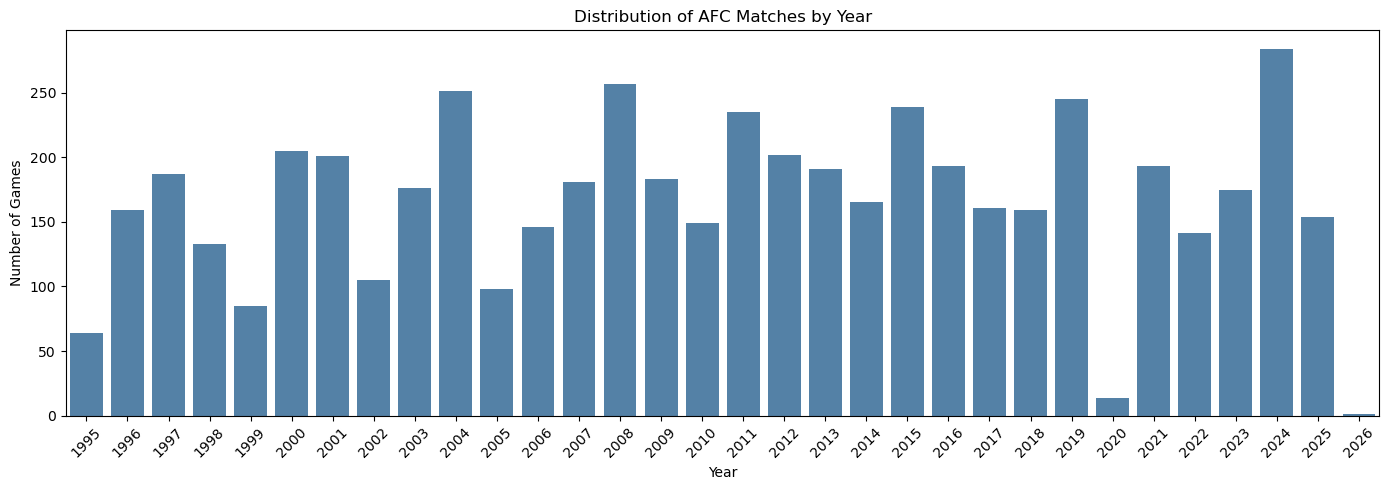

/tmp/ipykernel_1961/1072634083.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neutral_counts.index, y=neutral_counts.values, palette=['#2E86AB', '#F18F01'])


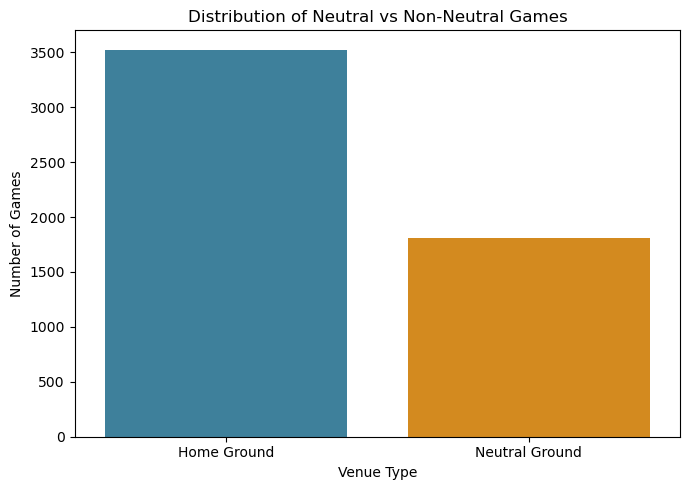

neutral
Home Ground       3524
Neutral Ground    1808
Name: count, dtype: int64

In [39]:
# Basic EDA: Distribution of matches by year, neutral vs non-neutral, scoreline distribution

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use whichever main match dataframe is already loaded in the notebook.
if 'afc_matches_since_2000' in globals():
    plot_df = afc_matches_since_2000.copy()
elif 'df' in globals():
    plot_df = df.copy()
else:
    raise NameError("No match dataframe found. Run the data-loading/preprocessing cells first.")

plot_df['date'] = pd.to_datetime(plot_df['date'], errors='coerce')

# 1) Distribution of games by year
matches_by_year = plot_df['date'].dt.year.value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.barplot(x=matches_by_year.index, y=matches_by_year.values, color='steelblue')
plt.title('Distribution of AFC Matches by Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2) Distribution of neutral-ground vs non-neutral games
neutral_counts = (
    plot_df['neutral']
    .map({True: 'Neutral Ground', False: 'Home Ground'})
    .value_counts()
    .reindex(['Home Ground', 'Neutral Ground'])
)

plt.figure(figsize=(7, 5))
sns.barplot(x=neutral_counts.index, y=neutral_counts.values, palette=['#2E86AB', '#F18F01'])
plt.title('Distribution of Neutral vs Non-Neutral Games')
plt.xlabel('Venue Type')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()

neutral_counts

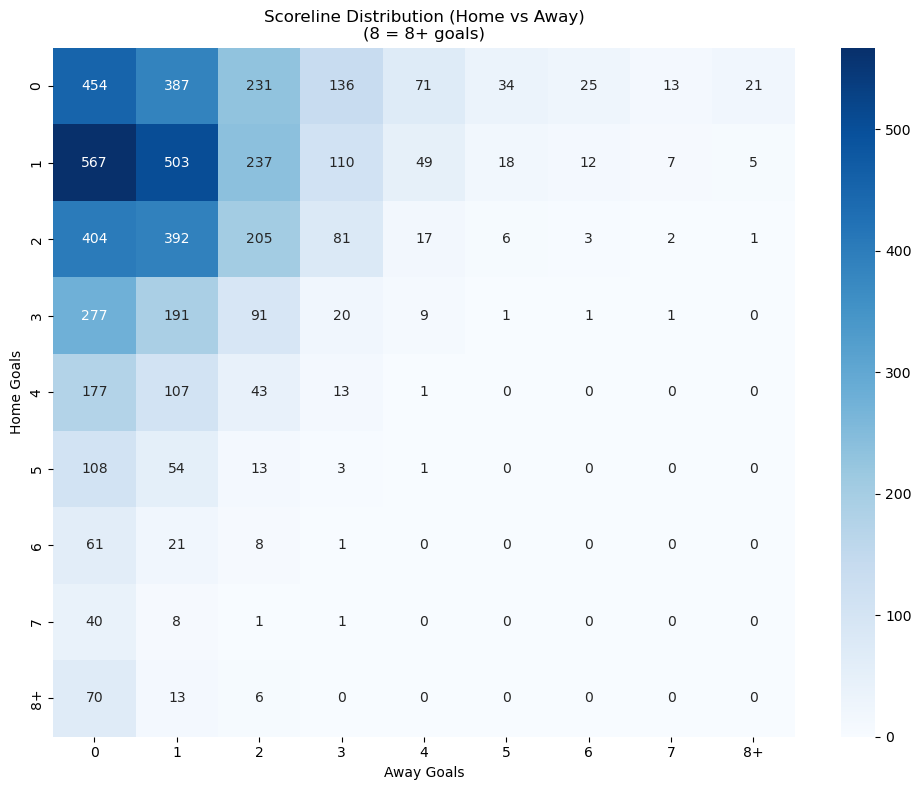

,0,1,2,3,4,5,6,7,8+
0,454,387,231,136,71,34,25,13,21
1,567,503,237,110,49,18,12,7,5
2,404,392,205,81,17,6,3,2,1
3,277,191,91,20,9,1,1,1,0
4,177,107,43,13,1,0,0,0,0
5,108,54,13,3,1,0,0,0,0
6,61,21,8,1,0,0,0,0,0
7,40,8,1,1,0,0,0,0,0
8+,70,13,6,0,0,0,0,0,0


In [40]:
# 3) Scoreline distribution (home vs away goals)

import matplotlib.pyplot as plt
import seaborn as sns
# Scoreline distribution grid (0-7, and 8+ bucket)
scoreline_grid = pd.crosstab(
    afc_matches_since_2000["home_score"].clip(upper=8),
    afc_matches_since_2000["away_score"].clip(upper=8)
).reindex(index=range(9), columns=range(9), fill_value=0)

# Rename 8 as "8+"
labels = [str(i) for i in range(8)] + ["8+"]
scoreline_grid.index = labels
scoreline_grid.columns = labels

plt.figure(figsize=(10, 8))
sns.heatmap(scoreline_grid, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Scoreline Distribution (Home vs Away)\n(8 = 8+ goals)")
plt.xlabel("Away Goals")
plt.ylabel("Home Goals")
plt.tight_layout()
plt.show()

scoreline_grid

In [41]:
# Create a table of Wins, Draws, Losses, and Win% for each team in Asia since 2000

stats_list = []

for team in teams_in_asia:
    # Filter matches where the team participated
    home = afc_matches_since_2000[afc_matches_since_2000['home_team'] == team]
    away = afc_matches_since_2000[afc_matches_since_2000['away_team'] == team]
    
    # Calculate Wins
    wins = (home['home_score'] > home['away_score']).sum() + \
           (away['away_score'] > away['home_score']).sum()
    
    # Calculate Losses
    losses = (home['home_score'] < home['away_score']).sum() + \
             (away['away_score'] < away['home_score']).sum()
    
    # Calculate Draws
    draws = (home['home_score'] == home['away_score']).sum() + \
            (away['away_score'] == away['home_score']).sum()
    
    played = wins + draws + losses
    
    # Calculate Win Percentage (Ratio)
    win_percentage = (wins / played * 100) if played > 0 else 0
    
    stats_list.append({
        'Team': team,
        'Played': played,
        'Wins': wins,
        'Draws': draws,
        'Losses': losses,
        'Win%': round(win_percentage, 2)
    })

# 4. Create and sort the final DataFrame
wdl_df = pd.DataFrame(stats_list).sort_values(by='Win%', ascending=False)

# Optional: Reset index for a clean table
wdl_df = wdl_df.reset_index(drop=True)

wdl_df

,Team,Played,Wins,Draws,Losses,Win%
0,Japan,247,163,46,38,65.99
1,Iran,295,187,71,37,63.39
2,Australia,163,97,35,31,59.51
3,South Korea,263,154,70,39,58.56
4,Saudi Arabia,345,197,77,71,57.10
5,Uzbekistan,279,142,54,83,50.90
6,Thailand,371,183,85,103,49.33
7,China PR,298,144,72,82,48.32
8,Qatar,345,164,85,96,47.54
9,Oman,360,170,92,98,47.22


In [42]:
# Look at the unique tournaments in the filtered matches
afc_matches_since_2000["tournament"].unique()

array(['Friendly', 'Dynasty Cup', "King's Cup", 'Nehru Cup', 'SAFF Cup',
       'Merdeka Tournament', 'Southeast Asian Games', 'South Asian Games',
       'AFC Asian Cup qualification',
       'United Arab Emirates Friendship Tournament', 'AFF Championship',
       'FIFA World Cup qualification', 'Gulf Cup', 'AFC Asian Cup',
       'Dunhill Cup', 'East Asian Games', 'Confederations Cup',
       'AFF Championship qualification', 'Arab Cup qualification',
       'Arab Cup', 'Asian Games', 'WAFF Championship', 'Millennium Cup',
       'Cup of Ancient Civilizations', "Prime Minister's Cup",
       'EAFF Championship', 'Kirin Cup', 'AFC Challenge Cup',
       'FIFA World Cup', 'AFC Challenge Cup qualification', 'VFF Cup',
       'Dragon Cup', 'Kirin Challenge Cup', 'Intercontinental Cup',
       'Three Nations Cup', 'Mahinda Rajapaksa Cup', 'Navruz Cup',
       'Jordan International Tournament', 'Tri Nation Tournament',
       'CAFA Nations Cup', 'FIFA Series', 'Marianas Cup',
       'ASEAN

In [43]:
# Define tournament weights based on importance

asian_world_quals = ['AFC Asian Cup qualification', 'FIFA World Cup qualification']
asian_world_finals = ['AFC Asian Cup', 'FIFA World Cup']
challenge_cup = ['AFC Challenge Cup', 'AFC Challenge Cup qualification']
regional_cups = ['WAFF Championship', 'AFF Championship', 'Gulf Cup', 'Arab Cup', 'SAFF Cup', 'EAFF Championship', 'East Asian Games', 'ASEAN Championship']
regional_cups_quals = ['AFF Championship qualification', 'Arab Cup qualification', 'ASEAN Championship qualification', 'EAFF Championship qualification']
def tournament_weight(tournament):
    if tournament in asian_world_quals:
        return 20
    elif tournament in asian_world_finals:
        return 25
    elif tournament in challenge_cup:
        return 15
    elif tournament in regional_cups:
        return 15
    elif tournament in regional_cups_quals:
        return 10
    elif tournament == 'Forfeited':
        return 1
    else:
        return 5

    

# Part 2: Data Engineering
## a) Glicko Rating handling

In [44]:
# Glicko-1 implementation with tournament weights and goal difference index, with a table to check for the final results

import math

# 1. Initialize Ratings and RD
# We use a dict of tuples: {team: (rating, RD)}
glicko_ratings = {team: (1500.0, 350.0) for team in teams_in_asia}

# Constants
q = math.log(10) / 400  # 0.0057565
c = 34.6                # Typical value for RD growth over time

def g(rd):
    """Calculates the 'g' factor based on opponent RD."""
    return 1 / math.sqrt(1 + 3 * (q**2) * (rd**2) / (math.pi**2))

def update_glicko(r1, rd1, r2, rd2, home_score, away_score, tournament):
    """
    r1, rd1: Current team
    r2, rd2: Opponent
    outcome: 1 for win, 0.5 for draw, 0 for loss
    """
    # 1. Standard Glicko constants
    q = math.log(10) / 400
    g_rd2 = 1 / math.sqrt(1 + 3 * (q**2) * (rd2**2) / (math.pi**2))
    expected = 1 / (1 + 10**(-g_rd2 * (r1 - r2) / 400))
    
    # 2. Determine Outcome (W)
    if home_score > away_score: outcome = 1
    elif home_score < away_score: outcome = 0
    else: outcome = 0.5
    
    # 3. Calculate Goal Difference Index (G) - From your provided formula
    n = abs(home_score - away_score)
    if n <= 1:
        g_index = 1
    elif n == 2:
        g_index = 1.5
    elif n == 3:
        g_index = 2
    elif n == 4:
        g_index = 2.25
    else:
        g_index = 1.75 + n / 8
        
    # 4. Get Tournament Weight (K)
    k = tournament_weight(tournament)
    
    # 5. Apply updates
    # We multiply the 'step' by (K/constant * G) 
    # Note: Standard Glicko doesn't use K, so we normalize K (usually 20 is standard)
    d_squared = 1 / (q**2 * g_rd2**2 * expected * (1 - expected))
    
    # New Rating calculation incorporating G and K
    # We use (K/20) as a multiplier to scale the Glicko update to match your tournament weights
    rating_change = (q / (1/rd1**2 + 1/d_squared)) * g_rd2 * (outcome - expected)
    new_r = r1 + (rating_change * g_index * (k/20))
    
    # New RD (Uncertainty usually decreases regardless of goal count)
    new_rd = math.sqrt(1 / (1/rd1**2 + 1/d_squared))
    
    return new_r, new_rd

# 2. Process matches
for index, row in afc_matches_since_2000.sort_values('date').iterrows():
    home, away = row['home_team'], row['away_team']
    
    r_h, rd_h = glicko_ratings[home]
    r_a, rd_a = glicko_ratings[away]
    
    # Update both (Note: In Glicko, we usually update RD for time passed too)
    new_rh, new_rdh = update_glicko(r_h, rd_h, r_a, rd_a, row['home_score'], row['away_score'], row['tournament'])
    new_ra, new_rda = update_glicko(r_a, rd_a, r_h, rd_h, row['away_score'], row['home_score'], row['tournament'])
    
    glicko_ratings[home] = (new_rh, new_rdh)
    glicko_ratings[away] = (new_ra, new_rda)

glicko_ratings

{'Afghanistan': (1244.3773938122833, 40.84428157991221),
 'Australia': (1929.6896078360999, 32.390671523083064),
 'Bahrain': (1700.366793146234, 20.107804801620055),
 'Bangladesh': (1204.3754554662444, 30.114882467931057),
 'Bhutan': (832.9587311316527, 59.840175129350506),
 'Brunei': (926.4629363006391, 45.95328198154247),
 'Cambodia': (1040.484828249075, 36.18165885928229),
 'China PR': (1775.752024794563, 23.961558688915986),
 'Taiwan': (1118.8942528803643, 44.776589323865586),
 'North Korea': (1643.249262594461, 27.987766477063374),
 'Guam': (886.1901050759251, 65.82971352532657),
 'Hong Kong': (1397.9215624435747, 30.982183363168357),
 'India': (1406.0990816500755, 27.412833458101602),
 'Indonesia': (1513.8553664356216, 25.523988274057128),
 'Iran': (1940.732758569362, 25.54293389124142),
 'Iraq': (1757.55248342769, 20.55381256057439),
 'Japan': (1967.8538327782517, 27.390636255241635),
 'Jordan': (1731.65202701442, 21.561830135049753),
 'Kuwait': (1697.3739671812564, 20.952050257

In [45]:
# Convert to DataFrame for better visualization and also sorting the teams by rating

glicko_df = pd.DataFrame.from_dict(glicko_ratings, orient='index', columns=['Rating', 'RD'])

glicko_df = glicko_df.reset_index().rename(columns={'index': 'Team'})


glicko_df['Lower_Bound'] = glicko_df['Rating'] - (2 * glicko_df['RD'])
glicko_df['Upper_Bound'] = glicko_df['Rating'] + (2 * glicko_df['RD'])

glicko_df = glicko_df.sort_values(by='Rating', ascending=False).reset_index(drop=True)

glicko_df = glicko_df.round(2)

glicko_df

,Team,Rating,RD,Lower_Bound,Upper_Bound
0,Japan,1967.85,27.39,1913.07,2022.64
1,Iran,1940.73,25.54,1889.65,1991.82
2,Australia,1929.69,32.39,1864.91,1994.47
3,South Korea,1919.38,25.15,1869.08,1969.67
4,Saudi Arabia,1849.73,23.38,1802.96,1896.50
5,Uzbekistan,1797.78,23.66,1750.46,1845.11
6,China PR,1775.75,23.96,1727.83,1823.68
7,Qatar,1766.96,21.06,1724.83,1809.08
8,Iraq,1757.55,20.55,1716.44,1798.66
9,Jordan,1731.65,21.56,1688.53,1774.78


In [46]:
# Use the above Glicko rating system to create a new dataframe that includes pre-match Glicko ratings for each team in each match
def get_pre_match_glicko(df, teams_list):
    """
    Creates a new dataframe with pre-match Glicko-1 scores for each team.
    Initial score: (1500.0, 350.0)
    """
    # Initialize ratings
    current_ratings = {team: (1500.0, 350.0) for team in teams_list}
    
    # Storage for the new data
    processed_data = []
    
    # Ensure chronological order
    df_sorted = df.sort_values('date').copy()
    
    for _, row in df_sorted.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        
        # Get pre-match ratings
        home_r, home_rd = current_ratings[home_team]
        away_r, away_rd = current_ratings[away_team]
        rating_diff = home_r - away_r
        
        # Store row data with pre-match ratings
        match_info = row.to_dict()
        match_info['home_glicko_rating'] = home_r
        match_info['home_glicko_rd'] = home_rd
        match_info['away_glicko_rating'] = away_r
        match_info['away_glicko_rd'] = away_rd
        match_info['glicko_rating_diff'] = rating_diff
        
        # We also need the ratings AFTER the game to facilitate the next step (form calculation)
        # However, the user wants this to be the draft dataframe for Glicko.
        
        # Update ratings after the match
        new_rh, new_rdh = update_glicko(home_r, home_rd, away_r, away_rd, 
                                        row['home_score'], row['away_score'], 
                                        row['tournament'])
        new_ra, new_rda = update_glicko(away_r, away_rd, home_r, home_rd, 
                                        row['away_score'], row['home_score'], 
                                        row['tournament'])
        
        match_info['home_glicko_rating_post'] = new_rh
        match_info['away_glicko_rating_post'] = new_ra
        
        processed_data.append(match_info)
        
        current_ratings[home_team] = (new_rh, new_rdh)
        current_ratings[away_team] = (new_ra, new_rda)
        
    return pd.DataFrame(processed_data)

# Create the processed dataframe (Draft for Step 2)
afc_matches_with_glicko = get_pre_match_glicko(afc_matches_since_2000, teams_in_asia)
afc_matches_with_glicko.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_glicko_rating,home_glicko_rd,away_glicko_rating,away_glicko_rd,glicko_rating_diff,home_glicko_rating_post,away_glicko_rating_post
0,1995-02-15,Australia,Japan,2,1,Friendly,Sydney,Australia,False,1500.000000,350.000000,1500.000000,350.000000,0.000000,1540.553001,1459.446999
1,1995-02-19,China PR,South Korea,0,0,Dynasty Cup,Victoria,Hong Kong,True,1500.000000,350.000000,1500.000000,350.000000,0.000000,1500.000000,1500.000000
2,1995-02-19,Hong Kong,Japan,0,3,Dynasty Cup,Victoria,Hong Kong,False,1500.000000,350.000000,1459.446999,290.230506,40.553001,1408.884766,1526.160774
3,1995-02-21,Hong Kong,China PR,0,0,Dynasty Cup,Victoria,Hong Kong,False,1408.884766,281.582486,1500.000000,290.230506,-91.115234,1414.840712,1493.646530
4,1995-02-21,Japan,South Korea,1,1,Dynasty Cup,Victoria,Hong Kong,True,1526.160774,253.529108,1500.000000,290.230506,26.160774,1524.698575,1501.945754


## b) Adding form and H2H features
Important features to see the current trajectory of the teams, including Win/Draw/Loss rates, Goals scored/conceeded, ELO of the wins/draws/losses, and H2H wins/draws/losses with goals scored/conceeded. For general form it's calculated for the last 10 matches, while for H2H it's calculated for the last 5 matches.

In [47]:
from collections import deque

def add_form_features(glicko_df, teams_list):
    """
    Takes the Glicko dataframe and adds last-10-games form features.
    """
    # Initialize history
    team_history = {team: deque(maxlen=10) for team in teams_list}

    # Storage for the new data
    processed_data = []

    # Crucial: glicko_df is already sorted by date from the previous step

    def calculate_streak(history):
        """
        Signed streak from most recent match backwards.
        Positive = undefeated streak (starts on a recent win).
        Negative = winless streak (starts on a recent draw/loss).
        """
        if not history:
            return 0

        recent = list(history)
        last = recent[-1]

        if last['W'] == 1:
            streak = 0
            for match in reversed(recent):
                if match['L'] == 0:
                    streak += 1
                else:
                    break
            return streak

        streak = 0
        for match in reversed(recent):
            if match['W'] == 0:
                streak += 1
            else:
                break
        return -streak

    def calculate_form(history):
        games_played = len(history)
        if not history:
            return 0, 0, 0, 0, 0, 1500.0, 0, 0, 0, 0, 0

        wins = sum(x['W'] for x in history)
        draws = sum(x['D'] for x in history)
        losses = sum(x['L'] for x in history)
        gf = sum(x['GF'] for x in history)
        ga = sum(x['GA'] for x in history)
        avg_opp_rating = sum(x['opp_post_rating'] for x in history) / games_played

        win_opp_ratings = [x['opp_post_rating'] for x in history if x['W'] == 1]
        draw_opp_ratings = [x['opp_post_rating'] for x in history if x['D'] == 1]
        loss_opp_ratings = [x['opp_post_rating'] for x in history if x['L'] == 1]

        avg_opp_rating_w = sum(win_opp_ratings) / len(win_opp_ratings) if win_opp_ratings else 0
        avg_opp_rating_d = sum(draw_opp_ratings) / len(draw_opp_ratings) if draw_opp_ratings else 0
        avg_opp_rating_l = sum(loss_opp_ratings) / len(loss_opp_ratings) if loss_opp_ratings else 0

        # Calculate ratios as requested (if games_played > 0)
        # All stats divided by games_played
        w_ratio = wins / games_played
        d_ratio = draws / games_played
        l_ratio = losses / games_played
        gf_ratio = gf / games_played
        ga_ratio = ga / games_played
        form_streak = calculate_streak(history)

        return (
            w_ratio,
            d_ratio,
            l_ratio,
            gf_ratio,
            ga_ratio,
            avg_opp_rating,
            games_played,
            avg_opp_rating_w,
            avg_opp_rating_d,
            avg_opp_rating_l,
            form_streak,
        )

    for _, row in glicko_df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']

        # 1. Get pre-match form stats
        (
            h_w,
            h_d,
            h_l,
            h_gf,
            h_ga,
            h_avg_opp,
            h_games,
            h_avg_opp_w,
            h_avg_opp_d,
            h_avg_opp_l,
            h_streak,
        ) = calculate_form(team_history[home_team])
        (
            a_w,
            a_d,
            a_l,
            a_gf,
            a_ga,
            a_avg_opp,
            a_games,
            a_avg_opp_w,
            a_avg_opp_d,
            a_avg_opp_l,
            a_streak,
        ) = calculate_form(team_history[away_team])

        # Store row data with form stats
        match_info = row.to_dict()
        match_info['home_form_W'] = h_w
        match_info['home_form_D'] = h_d
        match_info['home_form_L'] = h_l
        match_info['home_form_GF'] = h_gf
        match_info['home_form_GA'] = h_ga
        match_info['home_form_avg_opp_rating'] = h_avg_opp
        match_info['home_form_games_max10'] = h_games
        match_info['home_form_avg_opp_rating_W'] = h_avg_opp_w
        match_info['home_form_avg_opp_rating_D'] = h_avg_opp_d
        match_info['home_form_avg_opp_rating_L'] = h_avg_opp_l
        match_info['home_form_streak'] = h_streak

        match_info['away_form_W'] = a_w
        match_info['away_form_D'] = a_d
        match_info['away_form_L'] = a_l
        match_info['away_form_GF'] = a_gf
        match_info['away_form_GA'] = a_ga
        match_info['away_form_avg_opp_rating'] = a_avg_opp
        match_info['away_form_games_max10'] = a_games
        match_info['away_form_avg_opp_rating_W'] = a_avg_opp_w
        match_info['away_form_avg_opp_rating_D'] = a_avg_opp_d
        match_info['away_form_avg_opp_rating_L'] = a_avg_opp_l
        match_info['away_form_streak'] = a_streak

        processed_data.append(match_info)

        # 2. Update team history for the next matches
        h_score = row['home_score']
        a_score = row['away_score']

        if h_score > a_score:
            h_res = 'W'
        elif h_score < a_score:
            h_res = 'L'
        else:
            h_res = 'D'

        # Use post-match ratings as requested
        team_history[home_team].append({
            'W': 1 if h_res == 'W' else 0,
            'D': 1 if h_res == 'D' else 0,
            'L': 1 if h_res == 'L' else 0,
            'GF': h_score,
            'GA': a_score,
            'opp_post_rating': row['away_glicko_rating_post']
        })

        team_history[away_team].append({
            'W': 1 if h_res == 'L' else 0,
            'D': 1 if h_res == 'D' else 0,
            'L': 1 if h_res == 'W' else 0,
            'GF': a_score,
            'GA': h_score,
            'opp_post_rating': row['home_glicko_rating_post']
        })

    return pd.DataFrame(processed_data)

# Create the final processed dataframe with form features
afc_matches_with_features = add_form_features(afc_matches_with_glicko, teams_in_asia)
afc_matches_with_features

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_glicko_rating,...,away_form_D,away_form_L,away_form_GF,away_form_GA,away_form_avg_opp_rating,away_form_games_max10,away_form_avg_opp_rating_W,away_form_avg_opp_rating_D,away_form_avg_opp_rating_L,away_form_streak
0,1995-02-15,Australia,Japan,2,1,Friendly,Sydney,Australia,False,1500.000000,...,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0
1,1995-02-19,China PR,South Korea,0,0,Dynasty Cup,Victoria,Hong Kong,True,1500.000000,...,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0
2,1995-02-19,Hong Kong,Japan,0,3,Dynasty Cup,Victoria,Hong Kong,False,1500.000000,...,0.0,1.0,1.0,2.0,1540.553001,1,0.000000,0.000000,1540.553001,-1
3,1995-02-21,Hong Kong,China PR,0,0,Dynasty Cup,Victoria,Hong Kong,False,1408.884766,...,1.0,0.0,0.0,0.0,1500.000000,1,0.000000,1500.000000,0.000000,-1
4,1995-02-21,Japan,South Korea,1,1,Dynasty Cup,Victoria,Hong Kong,True,1526.160774,...,1.0,0.0,0.0,0.0,1500.000000,1,0.000000,1500.000000,0.000000,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5327,2025-12-09,United Arab Emirates,Kuwait,3,1,Arab Cup,Doha,Qatar,True,1721.868295,...,0.3,0.6,0.8,1.9,1728.817439,10,1723.425435,1720.865991,1733.691830,-9
5328,2025-12-11,Palestine,Saudi Arabia,1,2,Arab Cup,Lusail,Qatar,True,1532.544194,...,0.2,0.2,1.5,0.8,1757.683177,10,1699.639333,1863.157893,1826.339991,3
5329,2025-12-12,Jordan,Iraq,1,0,Arab Cup,Al Rayyan,Qatar,True,1729.227706,...,0.2,0.2,1.1,0.8,1670.296813,10,1615.069466,1787.086019,1719.189647,8
5330,2025-12-15,Saudi Arabia,Jordan,0,1,Arab Cup,Al Khor,Qatar,True,1851.298938,...,0.3,0.2,1.4,0.8,1738.188427,10,1683.159596,1786.789097,1802.859501,3


In [48]:
from collections import defaultdict, deque

def add_h2h_features(df):
    """
    Takes the dataframe with form features and computes the Head-2-Head 
    form for the last 5 matches strictly between the two playing teams. 
    """
    # Dictionary of deques: key is sorted tuple of (team1, team2)
    h2h_history = defaultdict(lambda: deque(maxlen=5))
    
    processed_data = []
    
    for _, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        
        # Unique key for this particular matchup regardless of who is home or away
        pair_key = tuple(sorted([home_team, away_team]))
        history = h2h_history[pair_key]
        
        # Calculate pre-match stats
        h2h_games_max5 = len(history)
        h2h_home_win = 0
        h2h_away_win = 0
        h2h_draw = 0
        h2h_home_goals = 0
        h2h_away_goals = 0
        
        for past_match in history:
            if past_match['winner'] == home_team:
                h2h_home_win += 1
            elif past_match['winner'] == away_team:
                h2h_away_win += 1
            else:
                h2h_draw += 1
            
            # Identify which score belongs to which current team
            if past_match['home'] == home_team:
                h2h_home_goals += past_match['h_score']
                h2h_away_goals += past_match['a_score']
            else:
                h2h_home_goals += past_match['a_score']
                h2h_away_goals += past_match['h_score']
                
        # Store in dict
        match_info = row.to_dict()
        
        # Calculate ratios as requested (if h2h_games_max5 > 0)
        # All stats divided by h2h_games_max5
        match_info['H2H_home_team_win'] = h2h_home_win / h2h_games_max5 if h2h_games_max5 > 0 else 0
        match_info['H2H_draw'] = h2h_draw / h2h_games_max5 if h2h_games_max5 > 0 else 0
        match_info['H2H_away_team_win'] = h2h_away_win / h2h_games_max5 if h2h_games_max5 > 0 else 0
        
        match_info['H2H_games_max5'] = h2h_games_max5
        match_info['H2H_home_team_score_avg'] = h2h_home_goals / h2h_games_max5 if h2h_games_max5 > 0 else 0
        match_info['H2H_away_team_score_avg'] = h2h_away_goals / h2h_games_max5 if h2h_games_max5 > 0 else 0
        
        processed_data.append(match_info)
        
        # Update history for next matches
        h_score = row['home_score']
        a_score = row['away_score']
        
        if h_score > a_score:
            winner = home_team
        elif h_score < a_score:
            winner = away_team
        else:
            winner = 'Draw'
            
        h2h_history[pair_key].append({
            'winner': winner,
            'home': home_team,
            'away': away_team,
            'h_score': h_score,
            'a_score': a_score
        })
        
    return pd.DataFrame(processed_data)

# Create the dataframe containing all previously generated features + new H2H features
afc_matches_with_h2h = add_h2h_features(afc_matches_with_features)
with pd.option_context('display.max_columns', None):
    display(afc_matches_with_h2h)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_glicko_rating,home_glicko_rd,away_glicko_rating,away_glicko_rd,glicko_rating_diff,home_glicko_rating_post,away_glicko_rating_post,home_form_W,home_form_D,home_form_L,home_form_GF,home_form_GA,home_form_avg_opp_rating,home_form_games_max10,home_form_avg_opp_rating_W,home_form_avg_opp_rating_D,home_form_avg_opp_rating_L,home_form_streak,away_form_W,away_form_D,away_form_L,away_form_GF,away_form_GA,away_form_avg_opp_rating,away_form_games_max10,away_form_avg_opp_rating_W,away_form_avg_opp_rating_D,away_form_avg_opp_rating_L,away_form_streak,H2H_home_team_win,H2H_draw,H2H_away_team_win,H2H_games_max5,H2H_home_team_score_avg,H2H_away_team_score_avg
0,1995-02-15,Australia,Japan,2,1,Friendly,Sydney,Australia,False,1500.000000,350.000000,1500.000000,350.000000,0.000000,1540.553001,1459.446999,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0,0.0,0.0
1,1995-02-19,China PR,South Korea,0,0,Dynasty Cup,Victoria,Hong Kong,True,1500.000000,350.000000,1500.000000,350.000000,0.000000,1500.000000,1500.000000,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0,0.0,0.0
2,1995-02-19,Hong Kong,Japan,0,3,Dynasty Cup,Victoria,Hong Kong,False,1500.000000,350.000000,1459.446999,290.230506,40.553001,1408.884766,1526.160774,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,1.0,1.0,2.0,1540.553001,1,0.000000,0.000000,1540.553001,-1,0.0,0.0,0.0,0,0.0,0.0
3,1995-02-21,Hong Kong,China PR,0,0,Dynasty Cup,Victoria,Hong Kong,False,1408.884766,281.582486,1500.000000,290.230506,-91.115234,1414.840712,1493.646530,0.0,0.0,1.0,0.0,3.0,1526.160774,1,0.000000,0.000000,1526.160774,-1,0.0,1.0,0.0,0.0,0.0,1500.000000,1,0.000000,1500.000000,0.000000,-1,0.0,0.0,0.0,0,0.0,0.0
4,1995-02-21,Japan,South Korea,1,1,Dynasty Cup,Victoria,Hong Kong,True,1526.160774,253.529108,1500.000000,290.230506,26.160774,1524.698575,1501.945754,0.5,0.0,0.5,2.0,1.0,1474.718883,2,1408.884766,0.000000,1540.553001,1,0.0,1.0,0.0,0.0,0.0,1500.000000,1,0.000000,1500.000000,0.000000,-1,0.0,0.0,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5327,2025-12-09,United Arab Emirates,Kuwait,3,1,Arab Cup,Doha,Qatar,True,1721.868295,21.012471,1698.698029,20.989914,23.170266,1723.195200,1697.373967,0.4,0.3,0.3,1.3,1.1,1697.339031,10,1675.373503,1672.487820,1751.477614,-4,0.1,0.3,0.6,0.8,1.9,1728.817439,10,1723.425435,1720.865991,1733.691830,-9,0.2,0.2,0.6,5,0.4,1.0
5328,2025-12-11,Palestine,Saudi Arabia,1,2,Arab Cup,Lusail,Qatar,True,1532.544194,31.265395,1850.971180,23.457102,-318.426986,1531.963600,1851.298938,0.3,0.4,0.3,1.0,1.0,1711.542385,10,1741.537532,1745.471758,1636.308073,-1,0.6,0.2,0.2,1.5,0.8,1757.683177,10,1699.639333,1863.157893,1826.339991,3,0.0,0.8,0.2,5,0.2,1.2
5329,2025-12-12,Jordan,Iraq,1,0,Arab Cup,Al Rayyan,Qatar,True,1729.227706,21.639996,1758.538686,20.589450,-29.310980,1730.316980,1757.552483,0.4,0.4,0.2,1.4,0.9,1732.963813,10,1664.561374,1766.418407,1802.859501,2,0.6,0.2,0.2,1.1,0.8,1670.296813,10,1615.069466,1787.086019,1719.189647,8,0.2,0.4,0.4,5,0.6,0.8
5330,2025-12-15,Saudi Arabia,Jordan,0,1,Arab Cup,Al Khor,Qatar,True,1851.298938,23.431807,1730.316980,21.598613,120.981959,1849.727798,1731.652027,0.6,0.2,0.2,1.4,0.8,1735.100601,10,1662.001706,1863.157893,1826.339991,4,0.5,0.3,0.2,1.4,0.8,1738.188427,10,1683.159596,1786.789097,1802.859501,3,0.4,0.0,0.6,5,1.0,1.2


## c) Adding misc features
Adding features like the team's height difference, scoring potential by the home and away teams, and  other stats like match results (which is important for later classification) and tournament weight

In [49]:
def add_misc_features(df):
    """
    Adds miscellaneous features such as:
    - Tournament weighting
    - Match result label
    - Team profile features by match year
      (home_team_age, home_team_height, away_team_age, away_team_height)
    - Additional engineered matchup features
      (glicko_rd_sum, height_difference, home_score_potential, away_score_potential)
    """
    df = df.copy()
    
    # Existing misc features
    df['tournament_weight'] = df['tournament'].apply(tournament_weight)
    df['result'] = df.apply(
        lambda row: 'Home Win' if row['home_score'] > row['away_score'] else ('Away Win' if row['home_score'] < row['away_score'] else 'Draw'),
        axis=1,
    )

    # Add team profile features from the scraper CSV loaded in Cell 3
    if 'country_year_profile_lookup' not in globals():
        raise ValueError("country_year_profile_lookup is missing. Run Cell 3 first.")

    df['match_year'] = pd.to_datetime(df['date'], errors='coerce').dt.year.astype('Int64')
    df['home_team_slug'] = df['home_team'].astype(str).apply(team_name_to_slug)
    df['away_team_slug'] = df['away_team'].astype(str).apply(team_name_to_slug)

    home_lookup = country_year_profile_lookup.rename(columns={
        'team_slug': 'home_team_slug',
        'team_age': 'home_team_age',
        'team_height': 'home_team_height',
    })
    away_lookup = country_year_profile_lookup.rename(columns={
        'team_slug': 'away_team_slug',
        'team_age': 'away_team_age',
        'team_height': 'away_team_height',
    })

    df = df.merge(
        home_lookup,
        left_on=['home_team_slug', 'match_year'],
        right_on=['home_team_slug', 'year'],
        how='left',
    ).drop(columns=['year'], errors='ignore')

    df = df.merge(
        away_lookup,
        left_on=['away_team_slug', 'match_year'],
        right_on=['away_team_slug', 'year'],
        how='left',
    ).drop(columns=['year'], errors='ignore')

    # Additional engineered features requested
    df['glicko_rd_sum'] = df['home_glicko_rd'] + df['away_glicko_rd']
    df['height_difference'] = df['home_team_height'] - df['away_team_height']
    df['home_score_potential'] = df['home_form_GF'] + df['away_form_GA']
    df['away_score_potential'] = df['away_form_GF'] + df['home_form_GA']

    df = df.drop(columns=['match_year', 'home_team_slug', 'away_team_slug'], errors='ignore')
    return df

afc_matches_final = add_misc_features(afc_matches_with_h2h)
afc_matches_final[
    [
        'date',
        'home_team',
        'away_team',
        'home_team_age',
        'home_team_height',
        'away_team_age',
        'away_team_height',
        'glicko_rd_sum',
        'height_difference',
        'home_score_potential',
        'away_score_potential',
    ]
] .head()

,date,home_team,away_team,home_team_age,home_team_height,away_team_age,away_team_height,glicko_rd_sum,height_difference,home_score_potential,away_score_potential
0,1995-02-15,Australia,Japan,24.6,1.84,25.6,1.77,700.000000,0.07,0.0,0.0
1,1995-02-19,China PR,South Korea,22.8,1.80,23.8,1.80,700.000000,0.00,0.0,0.0
2,1995-02-19,Hong Kong,Japan,0.0,0.00,25.6,1.77,640.230506,-1.77,2.0,1.0
3,1995-02-21,Hong Kong,China PR,0.0,0.00,22.8,1.80,571.812992,-1.80,0.0,3.0
4,1995-02-21,Japan,South Korea,25.6,1.77,23.8,1.80,543.759614,-0.03,2.0,1.0


In [59]:
# Define columns to exclude from X, either because they are identifiers, target variable, or features that is not going to be used in the model (e.g., post-match ratings, form features that leak future info, etc.)
exclude_cols = [
    'date', 'home_team', 'away_team', 'home_score', 'away_score', 
    'tournament', 'city', 'country', 'result', 
    'home_glicko_rating_post', 'away_glicko_rating_post','away_form_games_max10', 'home_form_games_max10', 'H2H_games_max5',
    'home_glicko_rd', 'away_glicko_rd', 'home_form_GF', 'home_form_GA', 'away_form_GF', 'away_form_GA', 'home_team_age', 'away_team_age',
    'home_form_streak', 'away_form_streak'
]

# Ensure result is encoded if needed (e.g., if you want numeric Y)
# result_mapping = {'Home Win': 1, 'Draw': 0, 'Away Win': -1}
# afc_matches_final['result_encoded'] = afc_matches_final['result'].map(result_mapping)

# Identify features present in the dataframe
features = [col for col in afc_matches_final.columns if col not in exclude_cols]

# Split function based on years
def split_by_year(df, train_range, val_range, test_range):
    train_df = df[(df['date'].get_year() >= train_range[0]) & (df['date'].get_year() <= train_range[1])]
    val_df = df[(df['date'].get_year() >= val_range[0]) & (df['date'].get_year() <= val_range[1])]
    test_df = df[(df['date'].get_year() >= test_range[0]) & (df['date'].get_year() <= test_range[1])]
    
    X_train, y_train = train_df[features], train_df['result']
    X_val, y_val = val_df[features], val_df['result']
    X_test, y_test = test_df[features], test_df['result']
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# Apply the split
# Note: Using .dt.year since 'date' is a datetime objects
train_mask = (afc_matches_final['date'].dt.year >= 1996) & (afc_matches_final['date'].dt.year <= 2019)
val_mask = (afc_matches_final['date'].dt.year >= 2020) & (afc_matches_final['date'].dt.year <= 2022)
test_mask = (afc_matches_final['date'].dt.year >= 2023) & (afc_matches_final['date'].dt.year <= 2026)

X_train, y_train = afc_matches_final.loc[train_mask, features], afc_matches_final.loc[train_mask, 'result']
X_val, y_val = afc_matches_final.loc[val_mask, features], afc_matches_final.loc[val_mask, 'result']
X_test, y_test = afc_matches_final.loc[test_mask, features], afc_matches_final.loc[test_mask, 'result']

print(f"Train set: {X_train.shape[0]} matches ({1996}-2020)")
print(f"Validation set: {X_val.shape[0]} matches (2021-2022)")
print(f"Test set: {X_test.shape[0]} matches (2023-2026)")

# Check feature list
print("\nFeatures used in X:")
print(features)

Train set: 4306 matches (1996-2020)
Validation set: 348 matches (2021-2022)
Test set: 614 matches (2023-2026)

Features used in X:
['neutral', 'home_glicko_rating', 'away_glicko_rating', 'glicko_rating_diff', 'home_form_W', 'home_form_D', 'home_form_L', 'home_form_avg_opp_rating', 'home_form_avg_opp_rating_W', 'home_form_avg_opp_rating_D', 'home_form_avg_opp_rating_L', 'away_form_W', 'away_form_D', 'away_form_L', 'away_form_avg_opp_rating', 'away_form_avg_opp_rating_W', 'away_form_avg_opp_rating_D', 'away_form_avg_opp_rating_L', 'H2H_home_team_win', 'H2H_draw', 'H2H_away_team_win', 'H2H_home_team_score_avg', 'H2H_away_team_score_avg', 'tournament_weight', 'home_team_height', 'away_team_height', 'glicko_rd_sum', 'height_difference', 'home_score_potential', 'away_score_potential']


# Part 3. Initialize and run the ML model
## a) Running a simple XGBoost model to look for what features are the most important

In [73]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss, classification_report, accuracy_score
import pandas as pd
import numpy as np

# 1. Encode targets
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

print(f"Classes found: {list(le.classes_)}")

# 2. Convert to DMatrix (optional but recommended for performance)
# Alternatively, use the Scikit-learn wrapper
model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    device='cpu' # specify 'cuda' if using GPU
)

# 3. Train the model with early stopping
model.fit(
    X_train, y_train_enc,
    eval_set=[(X_val, y_val_enc)],
    verbose=100
)

# 4. Predict probabilities on the Test set
test_probs = model.predict_proba(X_test)
test_preds = le.inverse_transform(model.predict(X_test))

# 5. Add probabilities back to a result dataframe for visualization
results_info = afc_matches_final.loc[test_mask, ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'result']].copy()

for i, class_name in enumerate(le.classes_):
    results_info[f'prob_{class_name}'] = test_probs[:, i]

results_info['predicted_result'] = test_preds

print("\nModel Evaluation (Test Set):")
print(f"Accuracy: {accuracy_score(y_test_enc, model.predict(X_test)):.4f}")
print(f"Log Loss: {log_loss(y_test_enc, test_probs):.4f}")

# Display first few predictions with probabilities
results_info[['date', 'home_team', 'away_team', 'result', 'predicted_result', 'prob_Home Win', 'prob_Draw', 'prob_Away Win']]

Classes found: ['Away Win', 'Draw', 'Home Win']
[0]	validation_0-mlogloss:0.97798
[100]	validation_0-mlogloss:0.74902
[148]	validation_0-mlogloss:0.75228

Model Evaluation (Test Set):
Accuracy: 0.6091
Log Loss: 0.8525


,date,home_team,away_team,result,predicted_result,prob_Home Win,prob_Draw,prob_Away Win
4718,2023-01-02,Philippines,Indonesia,Away Win,Away Win,0.301462,0.311106,0.387432
4719,2023-01-02,Thailand,Cambodia,Home Win,Home Win,0.956617,0.029794,0.013589
4720,2023-01-03,Vietnam,Myanmar,Home Win,Home Win,0.847531,0.109591,0.042878
4721,2023-01-03,Malaysia,Singapore,Home Win,Home Win,0.563299,0.266295,0.170406
4722,2023-01-06,Iraq,Oman,Draw,Draw,0.329561,0.352492,0.317947
...,...,...,...,...,...,...,...,...
5327,2025-12-09,United Arab Emirates,Kuwait,Home Win,Home Win,0.471322,0.324604,0.204074
5328,2025-12-11,Palestine,Saudi Arabia,Away Win,Away Win,0.131895,0.308075,0.560029
5329,2025-12-12,Jordan,Iraq,Home Win,Away Win,0.342987,0.312901,0.344112
5330,2025-12-15,Saudi Arabia,Jordan,Away Win,Home Win,0.437354,0.367216,0.195430


In [74]:
# Filter afc_matches_final for ASEAN Championship in 2024
asean_2024_matches = afc_matches_final[
    (afc_matches_final['tournament'] == 'ASEAN Championship') & 
    (afc_matches_final['date'].dt.year >= 2024)
].index

# Filter results_info (which already contains predictions) using those indices
asean_2024_predictions = results_info.loc[results_info.index.intersection(asean_2024_matches)]

# Display columns including probabilities and the final scores
display_cols = ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'result', 'predicted_result', 'prob_Home Win', 'prob_Draw', 'prob_Away Win']
asean_2024_predictions[display_cols].sort_values('date')

,date,home_team,away_team,home_score,away_score,result,predicted_result,prob_Home Win,prob_Draw,prob_Away Win
5134,2024-12-08,Cambodia,Malaysia,2,2,Draw,Away Win,0.093416,0.105547,0.801037
5135,2024-12-08,Timor-Leste,Thailand,0,10,Away Win,Away Win,0.036757,0.051274,0.911969
5137,2024-12-09,Laos,Vietnam,1,4,Away Win,Away Win,0.081920,0.078446,0.839634
5138,2024-12-09,Myanmar,Indonesia,0,1,Away Win,Away Win,0.169169,0.242429,0.588402
5140,2024-12-11,Malaysia,Timor-Leste,3,2,Home Win,Home Win,0.971680,0.019601,0.008719
5141,2024-12-11,Singapore,Cambodia,2,1,Home Win,Home Win,0.719376,0.222279,0.058345
5142,2024-12-12,Philippines,Myanmar,1,1,Draw,Home Win,0.631075,0.188730,0.180195
5143,2024-12-12,Indonesia,Laos,3,3,Draw,Home Win,0.938084,0.046066,0.015850
5144,2024-12-14,Timor-Leste,Singapore,0,3,Away Win,Away Win,0.085294,0.065707,0.848998
5145,2024-12-14,Thailand,Malaysia,1,0,Home Win,Home Win,0.582153,0.284508,0.133339


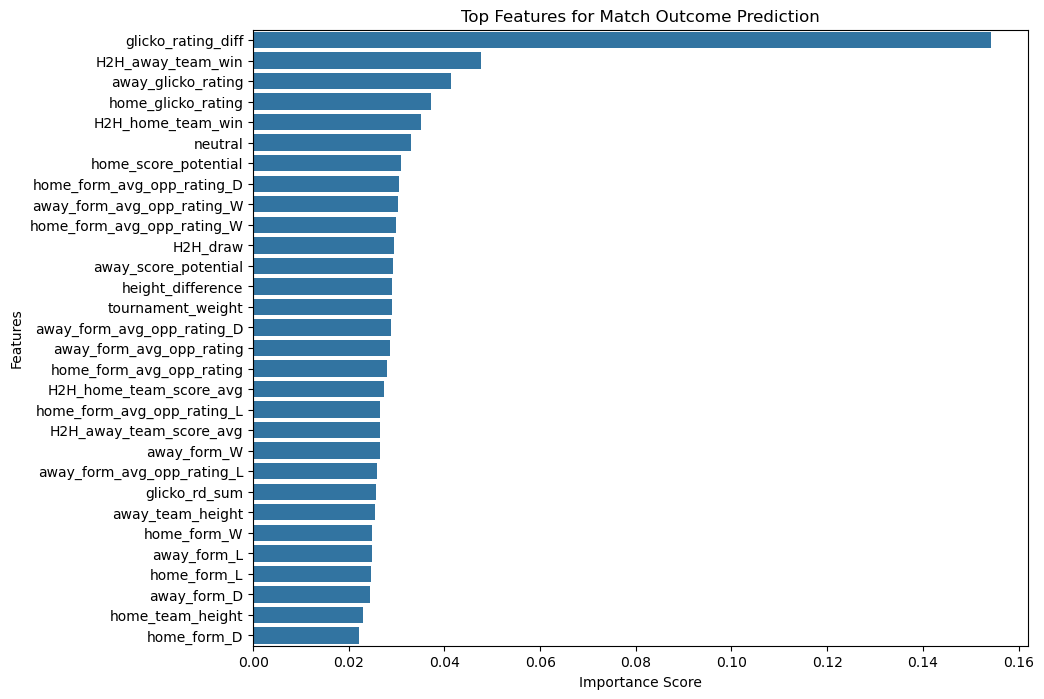

                       Feature  Importance
3           glicko_rating_diff    0.154303
20           H2H_away_team_win    0.047635
2           away_glicko_rating    0.041343
1           home_glicko_rating    0.037151
18           H2H_home_team_win    0.035156
0                      neutral    0.033070
28        home_score_potential    0.030978
9   home_form_avg_opp_rating_D    0.030479
15  away_form_avg_opp_rating_W    0.030330
8   home_form_avg_opp_rating_W    0.029810
19                    H2H_draw    0.029400
29        away_score_potential    0.029265
27           height_difference    0.029081
23           tournament_weight    0.028945
16  away_form_avg_opp_rating_D    0.028804
14    away_form_avg_opp_rating    0.028577
7     home_form_avg_opp_rating    0.027904
21     H2H_home_team_score_avg    0.027354
10  home_form_avg_opp_rating_L    0.026584
22     H2H_away_team_score_avg    0.026555
11                 away_form_W    0.026526
17  away_form_avg_opp_rating_L    0.025968
26         

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance from XGBoost model
feature_importance = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top Features for Match Outcome Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Display the numerical values
print(importance_df)

## b) Use Poisson + Dixon-Coles adjustment to help predict football expected goals and the final winner

In [86]:
from scipy.stats import poisson

# 1. Prepare target variables (Home and Away scores)
y_train_home = afc_matches_final.loc[train_mask, 'home_score']
y_train_away = afc_matches_final.loc[train_mask, 'away_score']

y_val_home = afc_matches_final.loc[val_mask, 'home_score']
y_val_away = afc_matches_final.loc[val_mask, 'away_score']

y_test_home = afc_matches_final.loc[test_mask, 'home_score']
y_test_away = afc_matches_final.loc[test_mask, 'away_score']

# 2. Define and train XGBoost Poisson models
params = {
    'objective': 'count:poisson',
    'eval_metric': 'poisson-nloglik',
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'early_stopping_rounds': 50,
    'random_state': 42
}

model_home = xgb.XGBRegressor(**params, n_estimators=1000)
model_away = xgb.XGBRegressor(**params, n_estimators=1000)

print("Training Home Score Model...")
model_home.fit(X_train, y_train_home, eval_set=[(X_val, y_val_home)], verbose=100)

print("\nTraining Away Score Model...")
model_away.fit(X_train, y_train_away, eval_set=[(X_val, y_val_away)], verbose=100)

# 3. Predict Lambda (expected goals) for Test Set
lambda_home = model_home.predict(X_test)
lambda_away = model_away.predict(X_test)

# 4. Calculate Probabilities using Poisson Distribution with Dixon-Coles Adjustment
def calculate_match_probs(l_home, l_away, max_goals=10, rho=-0.15, apply_dixoncoles=True):
    """
    Calculates win/draw/loss probabilities using Poisson distribution with Dixon-Coles adjustment.
    
    The Dixon-Coles adjustment applies τ(x,y) correction factors to specific low-scoring outcomes
    (0-0, 1-0, 0-1, 1-1) to better predict draws in international football.
    
    Parameters:
    -----------
    l_home : float
        Expected home team goals (lambda parameter)
    l_away : float
        Expected away team goals (mu parameter)
    max_goals : int
        Maximum goal count to compute (default=10)
    rho : float
        Dixon-Coles dependency parameter (default=-0.125, typical range -0.10 to -0.15 for international football)
    apply_dixoncoles : bool
        Whether to apply Dixon-Coles adjustment (default=True)
    
    Returns:
    --------
    tuple : (home_win_prob, draw_prob, away_win_prob)
    """
    # Probability of each score (0 to max_goals)
    prob_home = [poisson.pmf(i, l_home) for i in range(max_goals + 1)]
    prob_away = [poisson.pmf(i, l_away) for i in range(max_goals + 1)]
    
    # Outer product to get the score matrix
    score_matrix = np.outer(prob_home, prob_away)
    
    # Apply Dixon-Coles adjustment to specific score combinations
    if apply_dixoncoles:
        # τ factors for (x, y) pairs - these adjust for correlation in low-scoring outcomes
        tau_00 = 1 - (l_home * l_away * rho)      # (0,0) - tends to suppress 0-0s when rho < 0
        tau_10 = 1 + (l_away * rho)               # (1,0) - adjusts 1-0 probability
        tau_01 = 1 + (l_home * rho)               # (0,1) - adjusts 0-1 probability
        tau_11 = 1 - rho                          # (1,1) - tends to boost 1-1s when rho < 0
        
        # Apply adjustments (indexing: [i] = i goals, so [0,0] is first cell)
        score_matrix[0, 0] *= tau_00
        score_matrix[1, 0] *= tau_10
        score_matrix[0, 1] *= tau_01
        score_matrix[1, 1] *= tau_11
    
    home_win_prob = np.sum(np.tril(score_matrix, -1))
    away_win_prob = np.sum(np.triu(score_matrix, 1))
    draw_prob = np.sum(np.diag(score_matrix))
    
    # Normalize (due to max_goals truncation and possible adjustments)
    total = home_win_prob + away_win_prob + draw_prob
    return home_win_prob/total, draw_prob/total, away_win_prob/total

# Apply to test set
match_probs = [calculate_match_probs(lh, la) for lh, la in zip(lambda_home, lambda_away)]
match_probs_df = pd.DataFrame(match_probs, columns=['prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson'], index=X_test.index)

# Join with original results for comparison
poisson_results = afc_matches_final.loc[test_mask, ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'result']].copy()
poisson_results['expected_home_goals'] = lambda_home
poisson_results['expected_away_goals'] = lambda_away
poisson_results = pd.concat([poisson_results, match_probs_df], axis=1)

# Map predicted result based on highest probability
results_map = {0: 'Home Win', 1: 'Draw', 2: 'Away Win'}
poisson_results['predicted_result_Poisson'] = poisson_results[['prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson']].idxmax(axis=1).str.replace('prob_', '').str.replace('_Poisson', '')

poisson_results.head(10)

Training Home Score Model...
[0]	validation_0-poisson-nloglik:1.85885
[100]	validation_0-poisson-nloglik:1.54224
[200]	validation_0-poisson-nloglik:1.52640
[290]	validation_0-poisson-nloglik:1.52592

Training Away Score Model...
[0]	validation_0-poisson-nloglik:1.46762
[100]	validation_0-poisson-nloglik:1.23118
[200]	validation_0-poisson-nloglik:1.22486
[217]	validation_0-poisson-nloglik:1.22565


,date,home_team,away_team,home_score,away_score,result,expected_home_goals,expected_away_goals,prob_Home Win_Poisson,prob_Draw_Poisson,prob_Away Win_Poisson,predicted_result_Poisson
4718,2023-01-02,Philippines,Indonesia,1,2,Away Win,0.915664,1.225971,0.255946,0.330842,0.413211,Away Win
4719,2023-01-02,Thailand,Cambodia,3,1,Home Win,4.000257,0.418258,0.941780,0.048583,0.009638,Home Win
4720,2023-01-03,Vietnam,Myanmar,3,0,Home Win,2.310654,0.573908,0.755003,0.180720,0.064277,Home Win
4721,2023-01-03,Malaysia,Singapore,4,1,Home Win,1.179742,0.927664,0.396592,0.335628,0.267780,Home Win
4722,2023-01-06,Iraq,Oman,0,0,Draw,0.987538,0.943322,0.333962,0.355569,0.310469,Draw
4723,2023-01-06,Yemen,Saudi Arabia,0,2,Away Win,0.422448,3.033489,0.022675,0.099119,0.878205,Away Win
4724,2023-01-06,Indonesia,Vietnam,0,0,Draw,1.238981,1.141395,0.365342,0.316801,0.317856,Home Win
4725,2023-01-07,Malaysia,Thailand,1,0,Home Win,0.890147,1.094145,0.272563,0.347897,0.379540,Away Win
4726,2023-01-07,Bahrain,United Arab Emirates,2,1,Home Win,0.686447,0.822957,0.259028,0.402155,0.338817,Draw
4727,2023-01-07,Kuwait,Qatar,0,2,Away Win,0.601005,1.376119,0.145331,0.313313,0.541356,Away Win


In [87]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# 1. Compare Accuracy of Poisson approach
poisson_acc = accuracy_score(poisson_results['result'], poisson_results['predicted_result_Poisson'])
# Assuming 'results_info' still holds the previous classifier's results
classifier_acc = accuracy_score(results_info['result'], results_info['predicted_result'])

# 2. Multiclass Brier score (lower is better)
class_order = ['Home Win', 'Draw', 'Away Win']

# Classifier Brier
clf_true = pd.get_dummies(results_info['result']).reindex(columns=class_order, fill_value=0).to_numpy()
clf_prob = results_info[['prob_Home Win', 'prob_Draw', 'prob_Away Win']].reindex(columns=['prob_Home Win', 'prob_Draw', 'prob_Away Win']).to_numpy()
classifier_brier = np.mean(np.sum((clf_prob - clf_true) ** 2, axis=1))

# Poisson Brier
poi_true = pd.get_dummies(poisson_results['result']).reindex(columns=class_order, fill_value=0).to_numpy()
poi_prob = poisson_results[['prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson']].rename(columns={
    'prob_Home Win_Poisson': 'Home Win',
    'prob_Draw_Poisson': 'Draw',
    'prob_Away Win_Poisson': 'Away Win',
})[class_order].to_numpy()
poisson_brier = np.mean(np.sum((poi_prob - poi_true) ** 2, axis=1))

print(f"XGBoost Classifier Accuracy: {classifier_acc:.4f}")
print(f"Poisson XGBoost Accuracy:    {poisson_acc:.4f}")
print(f"XGBoost Classifier Brier:    {classifier_brier:.4f}")
print(f"Poisson XGBoost Brier:       {poisson_brier:.4f}")

# 3. Display ASEAN Championship matches from 2024 onward with Poisson probabilities
asean_2024_mask = (
    (afc_matches_final.loc[test_mask, 'tournament'] == 'ASEAN Championship') &
    (afc_matches_final.loc[test_mask, 'date'].dt.year >= 2024)
)

poisson_results.loc[
    asean_2024_mask,
    [
        'date', 'home_team', 'away_team',
        'expected_home_goals', 'expected_away_goals',
        'prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson',
        'result', 'predicted_result_Poisson'
    ]
]

XGBoost Classifier Accuracy: 0.6091
Poisson XGBoost Accuracy:    0.6075
XGBoost Classifier Brier:    0.4999
Poisson XGBoost Brier:       0.4925


,date,home_team,away_team,expected_home_goals,expected_away_goals,prob_Home Win_Poisson,prob_Draw_Poisson,prob_Away Win_Poisson,result,predicted_result_Poisson
5134,2024-12-08,Cambodia,Malaysia,0.631562,2.026021,0.091569,0.219879,0.688552,Draw,Away Win
5135,2024-12-08,Timor-Leste,Thailand,0.400411,5.635511,0.002217,0.013734,0.984049,Away Win,Away Win
5137,2024-12-09,Laos,Vietnam,0.601126,2.189008,0.075420,0.197280,0.727300,Away Win,Away Win
5138,2024-12-09,Myanmar,Indonesia,0.735847,1.433972,0.173946,0.306620,0.519435,Away Win,Away Win
5140,2024-12-11,Malaysia,Timor-Leste,5.633461,0.373438,0.985035,0.013027,0.001938,Home Win,Home Win
5141,2024-12-11,Singapore,Cambodia,2.038567,0.499088,0.726283,0.206535,0.067182,Home Win,Home Win
5142,2024-12-12,Philippines,Myanmar,1.634068,0.641059,0.598343,0.274458,0.127200,Draw,Home Win
5143,2024-12-12,Indonesia,Laos,3.680460,0.311850,0.938995,0.052988,0.008016,Draw,Home Win
5144,2024-12-14,Timor-Leste,Singapore,0.762919,4.043828,0.026064,0.068748,0.905188,Away Win,Away Win
5145,2024-12-14,Thailand,Malaysia,1.601948,0.653879,0.586680,0.279795,0.133525,Home Win,Home Win


## c) Performance Review
Compares model performance across three rating-gap bands.

- Metrics: Accuracy and Brier Score
- Purpose: Check where predictions are strongest or weakest

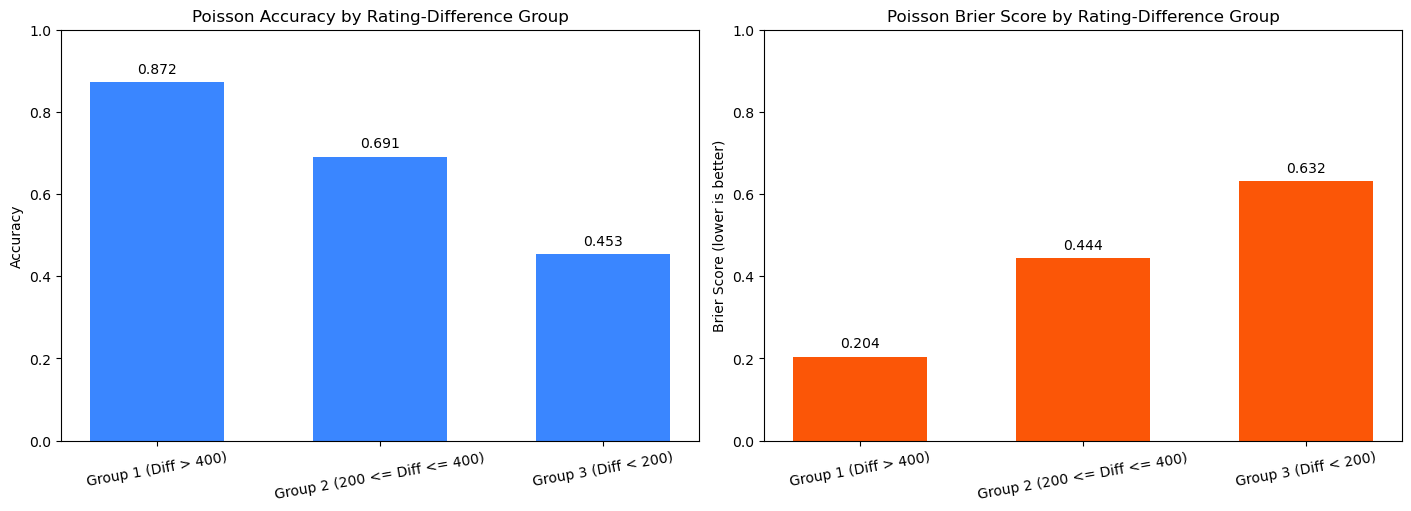

,Group,Accuracy,Brier Score
0,Group 1 (Diff > 400),0.871560,0.204415
1,Group 2 (200 <= Diff <= 400),0.690821,0.443932
2,Group 3 (Diff < 200),0.453020,0.631653


In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# 1. Add the Glicko rating difference to the results for grouping
poisson_results['rating_diff'] = (
    afc_matches_final.loc[test_mask, 'home_glicko_rating'] -
    afc_matches_final.loc[test_mask, 'away_glicko_rating']
).abs()

# 2. Define groups based on rating difference
groups = [
    ('Group 1 (Diff > 400)', poisson_results['rating_diff'] > 400),
    ('Group 2 (200 <= Diff <= 400)', (poisson_results['rating_diff'] >= 200) & (poisson_results['rating_diff'] <= 400)),
    ('Group 3 (Diff < 200)', poisson_results['rating_diff'] < 200),
]

# 3. Collect Accuracy + Brier per group
labels = []
accuracies = []
brier_scores = []

class_order = ['Home Win', 'Draw', 'Away Win']

for group_name, mask in groups:
    group_data = poisson_results[mask]
    labels.append(group_name)

    if len(group_data) == 0:
        accuracies.append(np.nan)
        brier_scores.append(np.nan)
        continue

    acc = accuracy_score(group_data['result'], group_data['predicted_result_Poisson'])

    y_true = pd.get_dummies(group_data['result']).reindex(columns=class_order, fill_value=0).to_numpy()
    y_prob = group_data[['prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson']].rename(columns={
        'prob_Home Win_Poisson': 'Home Win',
        'prob_Draw_Poisson': 'Draw',
        'prob_Away Win_Poisson': 'Away Win',
    })[class_order].to_numpy()
    brier = np.mean(np.sum((y_prob - y_true) ** 2, axis=1))

    accuracies.append(acc)
    brier_scores.append(brier)

# 4. Plot group-wise metrics
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

bars_acc = axes[0].bar(x, accuracies, color='#3A86FF', width=0.6)
axes[0].set_title('Poisson Accuracy by Rating-Difference Group')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=10)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for bar in bars_acc:
    h = bar.get_height()
    if np.isfinite(h):
        axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.015, f'{h:.3f}', ha='center', va='bottom', fontsize=10)

bars_brier = axes[1].bar(x, brier_scores, color='#FB5607', width=0.6)
axes[1].set_title('Poisson Brier Score by Rating-Difference Group')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=10)
axes[1].set_ylabel('Brier Score (lower is better)')
max_brier = np.nanmax(brier_scores) if np.isfinite(np.nanmax(brier_scores)) else 1.0
axes[1].set_ylim(0, max(1.0, max_brier * 1.15))
for bar in bars_brier:
    h = bar.get_height()
    if np.isfinite(h):
        axes[1].text(bar.get_x() + bar.get_width() / 2, h + 0.015, f'{h:.3f}', ha='center', va='bottom', fontsize=10)

plt.show()

# Optional summary table
pd.DataFrame({
    'Group': labels,
    'Accuracy': accuracies,
    'Brier Score': brier_scores
})

### Confusion Matrices by Rating-Difference Group
Shows class-level prediction behavior (Home Win, Draw, Away Win) within each rating-gap band.

- Values: Raw counts and row-normalized percentages
- Purpose: Identify which outcomes are confused most often

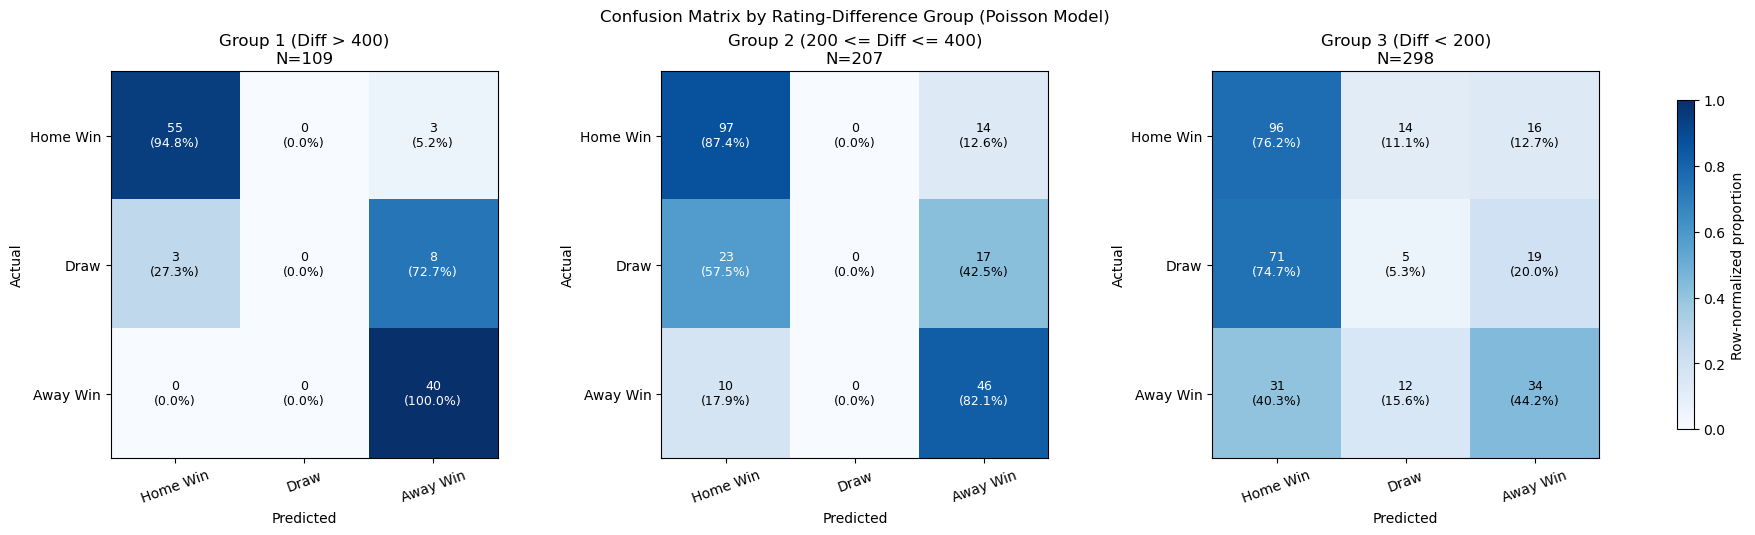

{'Group 1 (Diff > 400)':                   Pred: Home Win  Pred: Draw  Pred: Away Win
 Actual: Home Win              55           0               3
 Actual: Draw                   3           0               8
 Actual: Away Win               0           0              40,
 'Group 2 (200 <= Diff <= 400)':                   Pred: Home Win  Pred: Draw  Pred: Away Win
 Actual: Home Win              97           0              14
 Actual: Draw                  23           0              17
 Actual: Away Win              10           0              46,
 'Group 3 (Diff < 200)':                   Pred: Home Win  Pred: Draw  Pred: Away Win
 Actual: Home Win              96          14              16
 Actual: Draw                  71           5              19
 Actual: Away Win              31          12              34}

In [89]:
from sklearn.metrics import confusion_matrix

# Ensure groups exist if this cell is run independently
if 'groups' not in globals():
    poisson_results['rating_diff'] = (
        afc_matches_final.loc[test_mask, 'home_glicko_rating']
        - afc_matches_final.loc[test_mask, 'away_glicko_rating']
    ).abs()
    groups = [
        ('Group 1 (Diff > 400)', poisson_results['rating_diff'] > 400),
        ('Group 2 (200 <= Diff <= 400)', (poisson_results['rating_diff'] >= 200) & (poisson_results['rating_diff'] <= 400)),
        ('Group 3 (Diff < 200)', poisson_results['rating_diff'] < 200),
    ]

# Try to keep class order intuitive, with Draw in the middle when possible
preferred_orders = [
    ['Home Win', 'Draw', 'Away Win'],
    ['H', 'D', 'A'],
    ['home', 'draw', 'away'],
    ['Win', 'Draw', 'Loss'],
]
all_labels = pd.Index(poisson_results['result']).union(pd.Index(poisson_results['predicted_result_Poisson'])).tolist()
class_labels = None
for order in preferred_orders:
    if set(order).issubset(set(all_labels)):
        class_labels = order
        break
if class_labels is None:
    class_labels = sorted(all_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (group_name, mask) in zip(axes, groups):
    group_data = poisson_results[mask]

    if group_data.empty:
        ax.set_title(f'{group_name}\n(no matches)')
        ax.axis('off')
        continue

    y_true = group_data['result']
    y_pred = group_data['predicted_result_Poisson']

    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{group_name}\nN={len(group_data)}')
    ax.set_xticks(np.arange(len(class_labels)))
    ax.set_yticks(np.arange(len(class_labels)))
    ax.set_xticklabels(class_labels, rotation=20)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Show both raw counts and row-normalized percentage in each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt_color = 'white' if cm_norm[i, j] > 0.55 else 'black'
            ax.text(
                j,
                i,
                f"{cm[i, j]}\n({cm_norm[i, j]:.1%})",
                ha='center',
                va='center',
                color=txt_color,
                fontsize=9,
            )

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label('Row-normalized proportion')
plt.suptitle('Confusion Matrix by Rating-Difference Group (Poisson Model)', y=1.04)
plt.show()

# Optional: table view of per-group confusion matrices (raw counts)
cm_tables = {}
for group_name, mask in groups:
    group_data = poisson_results[mask]
    if group_data.empty:
        continue
    cm = confusion_matrix(group_data['result'], group_data['predicted_result_Poisson'], labels=class_labels)
    cm_tables[group_name] = pd.DataFrame(cm, index=[f'Actual: {c}' for c in class_labels], columns=[f'Pred: {c}' for c in class_labels])

cm_tables

# Part 4: Predict Fixtures for 31-03-2026
Builds pre-match features from historical data, estimates expected goals, and converts them into result probabilities.

- Inputs: Upcoming fixtures and team histories
- Outputs: Expected goals, win/draw/win probabilities, final predicted result

In [91]:
from collections import defaultdict, deque
from scipy.stats import poisson
import numpy as np
import pandas as pd

# Fixtures to predict (all on 31-03-2026)
match_date = pd.Timestamp('2026-03-31')
fixtures_input = [
    ('Maldives', 'Timor-Leste'),
    ('Tajikistan', 'Philippines'),
    ('Bhutan', 'Brunei'),
    ('Singapore', 'Bangladesh'),
    ('India', 'Hong Kong'),
    ('Chinese Taipei', 'Sri Lanka'),
    ('Thailand', 'Turkmenistan'),
    ('Pakistan', 'Myanmar'),
    ('Syria', 'Afghanistan'),
    ('Vietnam', 'Malaysia'),
    ('Laos', 'Nepal'),
]

# Name normalization to match model/training naming
team_alias = {
    'Chinese Taipei': 'Taiwan',
}


def normalize_team_name(team_name: str) -> str:
    return team_alias.get(team_name, team_name)


def get_form_stats(history):
    if not history:
        return {
            'W': 0.0, 'D': 0.0, 'L': 0.0,
            'GF': 0.0, 'GA': 0.0,
            'avg_opp': 1500.0,
            'games': 0,
            'avg_opp_W': 0.0,
            'avg_opp_D': 0.0,
            'avg_opp_L': 0.0,
        }

    n = len(history)
    wins = sum(x['W'] for x in history)
    draws = sum(x['D'] for x in history)
    losses = sum(x['L'] for x in history)
    gf = sum(x['GF'] for x in history)
    ga = sum(x['GA'] for x in history)
    avg_opp = sum(x['opp_post_rating'] for x in history) / n

    win_opp = [x['opp_post_rating'] for x in history if x['W'] == 1]
    draw_opp = [x['opp_post_rating'] for x in history if x['D'] == 1]
    loss_opp = [x['opp_post_rating'] for x in history if x['L'] == 1]

    return {
        'W': wins / n,
        'D': draws / n,
        'L': losses / n,
        'GF': gf / n,
        'GA': ga / n,
        'avg_opp': avg_opp,
        'games': n,
        'avg_opp_W': (sum(win_opp) / len(win_opp)) if win_opp else 0.0,
        'avg_opp_D': (sum(draw_opp) / len(draw_opp)) if draw_opp else 0.0,
        'avg_opp_L': (sum(loss_opp) / len(loss_opp)) if loss_opp else 0.0,
    }


def get_team_profile_features(team_name, target_year=2026):
    if 'country_year_profile_lookup' not in globals():
        return 0.0, 0.0

    team_slug = team_name_to_slug(team_name) if 'team_name_to_slug' in globals() else str(team_name).replace('-', '_').replace(' ', '_')
    team_rows = country_year_profile_lookup[country_year_profile_lookup['team_slug'] == team_slug]
    if team_rows.empty:
        return 0.0, 0.0

    exact = team_rows[team_rows['year'] == target_year]
    if not exact.empty:
        chosen = exact.iloc[-1]
    else:
        past = team_rows[team_rows['year'] <= target_year]
        chosen = past.sort_values('year').iloc[-1] if not past.empty else team_rows.sort_values('year').iloc[-1]

    age = float(chosen['team_age']) if pd.notna(chosen['team_age']) else 0.0
    height = float(chosen['team_height']) if pd.notna(chosen['team_height']) else 0.0
    return age, height


def calculate_match_probs_local(l_home, l_away, max_goals=10, rho=-0.125, apply_dixoncoles=True):
    # Use notebook-defined version if present
    if 'calculate_match_probs' in globals():
        return calculate_match_probs(l_home, l_away, max_goals=max_goals, rho=rho, apply_dixoncoles=apply_dixoncoles)

    prob_home = [poisson.pmf(i, l_home) for i in range(max_goals + 1)]
    prob_away = [poisson.pmf(i, l_away) for i in range(max_goals + 1)]
    score_matrix = np.outer(prob_home, prob_away)

    if apply_dixoncoles:
        tau_00 = 1 - (l_home * l_away * rho)
        tau_10 = 1 + (l_away * rho)
        tau_01 = 1 + (l_home * rho)
        tau_11 = 1 - rho
        score_matrix[0, 0] *= tau_00
        score_matrix[1, 0] *= tau_10
        score_matrix[0, 1] *= tau_01
        score_matrix[1, 1] *= tau_11

    home_win_prob = np.sum(np.tril(score_matrix, -1))
    away_win_prob = np.sum(np.triu(score_matrix, 1))
    draw_prob = np.sum(np.diag(score_matrix))
    total = home_win_prob + away_win_prob + draw_prob
    return home_win_prob / total, draw_prob / total, away_win_prob / total


# Build team states strictly from matches before 31-03-2026
hist_df = afc_matches_since_2000[afc_matches_since_2000['date'] < match_date].sort_values('date').copy()

ratings = {team: (1500.0, 350.0) for team in teams_in_asia}
form_hist = {team: deque(maxlen=10) for team in teams_in_asia}
h2h_hist = defaultdict(lambda: deque(maxlen=5))

for _, row in hist_df.iterrows():
    home = row['home_team']
    away = row['away_team']
    h_score = row['home_score']
    a_score = row['away_score']

    r_h, rd_h = ratings[home]
    r_a, rd_a = ratings[away]

    new_rh, new_rdh = update_glicko(r_h, rd_h, r_a, rd_a, h_score, a_score, row['tournament'])
    new_ra, new_rda = update_glicko(r_a, rd_a, r_h, rd_h, a_score, h_score, row['tournament'])

    ratings[home] = (new_rh, new_rdh)
    ratings[away] = (new_ra, new_rda)

    h_res = 'W' if h_score > a_score else ('L' if h_score < a_score else 'D')
    form_hist[home].append({
        'W': 1 if h_res == 'W' else 0,
        'D': 1 if h_res == 'D' else 0,
        'L': 1 if h_res == 'L' else 0,
        'GF': h_score,
        'GA': a_score,
        'opp_post_rating': new_ra,
    })
    form_hist[away].append({
        'W': 1 if h_res == 'L' else 0,
        'D': 1 if h_res == 'D' else 0,
        'L': 1 if h_res == 'W' else 0,
        'GF': a_score,
        'GA': h_score,
        'opp_post_rating': new_rh,
    })

    pair_key = tuple(sorted([home, away]))
    winner = home if h_score > a_score else (away if h_score < a_score else 'Draw')
    h2h_hist[pair_key].append({
        'winner': winner,
        'home': home,
        'away': away,
        'h_score': h_score,
        'a_score': a_score,
    })


# Build feature rows and predict
pred_rows = []
for home_raw, away_raw in fixtures_input:
    home = normalize_team_name(home_raw)
    away = normalize_team_name(away_raw)

    if home not in ratings or away not in ratings:
        raise ValueError(f'Unknown team name in fixture: {home_raw} vs {away_raw}')

    h_r, h_rd = ratings[home]
    a_r, a_rd = ratings[away]

    h_form = get_form_stats(form_hist[home])
    a_form = get_form_stats(form_hist[away])

    pair_key = tuple(sorted([home, away]))
    history = h2h_hist[pair_key]
    h2h_n = len(history)

    h2h_home_win = sum(1 for x in history if x['winner'] == home)
    h2h_away_win = sum(1 for x in history if x['winner'] == away)
    h2h_draw = sum(1 for x in history if x['winner'] == 'Draw')

    h2h_home_goals = 0
    h2h_away_goals = 0
    for past in history:
        if past['home'] == home:
            h2h_home_goals += past['h_score']
            h2h_away_goals += past['a_score']
        else:
            h2h_home_goals += past['a_score']
            h2h_away_goals += past['h_score']

    home_age, home_height = get_team_profile_features(home, target_year=2026)
    away_age, away_height = get_team_profile_features(away, target_year=2026)

    match_features = {
        'neutral': False,
        'home_glicko_rating': h_r,
        'home_glicko_rd': h_rd,
        'away_glicko_rating': a_r,
        'away_glicko_rd': a_rd,
        'home_form_W': h_form['W'],
        'home_form_D': h_form['D'],
        'home_form_L': h_form['L'],
        'home_form_GF': h_form['GF'],
        'home_form_GA': h_form['GA'],
        'home_form_avg_opp_rating': h_form['avg_opp'],
        'home_form_games_max10': h_form['games'],
        'home_form_avg_opp_rating_W': h_form['avg_opp_W'],
        'home_form_avg_opp_rating_D': h_form['avg_opp_D'],
        'home_form_avg_opp_rating_L': h_form['avg_opp_L'],
        'away_form_W': a_form['W'],
        'away_form_D': a_form['D'],
        'away_form_L': a_form['L'],
        'away_form_GF': a_form['GF'],
        'away_form_GA': a_form['GA'],
        'away_form_avg_opp_rating': a_form['avg_opp'],
        'away_form_games_max10': a_form['games'],
        'away_form_avg_opp_rating_W': a_form['avg_opp_W'],
        'away_form_avg_opp_rating_D': a_form['avg_opp_D'],
        'away_form_avg_opp_rating_L': a_form['avg_opp_L'],
        'H2H_home_team_win': (h2h_home_win / h2h_n) if h2h_n > 0 else 0.0,
        'H2H_draw': (h2h_draw / h2h_n) if h2h_n > 0 else 0.0,
        'H2H_away_team_win': (h2h_away_win / h2h_n) if h2h_n > 0 else 0.0,
        'H2H_games_max5': h2h_n,
        'H2H_home_team_score_avg': (h2h_home_goals / h2h_n) if h2h_n > 0 else 0.0,
        'H2H_away_team_score_avg': (h2h_away_goals / h2h_n) if h2h_n > 0 else 0.0,
        'tournament_weight': 15,
        'home_team_age': home_age,
        'home_team_height': home_height,
        'away_team_age': away_age,
        'away_team_height': away_height,
        'glicko_rd_sum': h_rd + a_rd,
        'height_difference': home_height - away_height,
        'home_score_potential': h_form['GF'] + a_form['GA'],
        'away_score_potential': a_form['GF'] + h_form['GA'],
    }

    X_one = pd.DataFrame([match_features]).reindex(columns=features, fill_value=0).fillna(0)

    exp_home_goals = float(model_home.predict(X_one)[0])
    exp_away_goals = float(model_away.predict(X_one)[0])

    p_home, p_draw, p_away = calculate_match_probs_local(exp_home_goals, exp_away_goals)

    pred_rows.append({
        'date': match_date.date(),
        'home_team': home_raw,
        'away_team': away_raw,
        'expected_home_goals': exp_home_goals,
        'expected_away_goals': exp_away_goals,
        'prob_home_win': p_home,
        'prob_draw': p_draw,
        'prob_away_win': p_away,
    })

pred_31mar2026 = pd.DataFrame(pred_rows)
pred_31mar2026['predicted_result'] = pred_31mar2026[['prob_home_win', 'prob_draw', 'prob_away_win']].idxmax(axis=1).map({
    'prob_home_win': 'Home Win',
    'prob_draw': 'Draw',
    'prob_away_win': 'Away Win',
})

# Readable formatting
for c in ['expected_home_goals', 'expected_away_goals', 'prob_home_win', 'prob_draw', 'prob_away_win']:
    pred_31mar2026[c] = pred_31mar2026[c].round(4)

display(pred_31mar2026)

,date,home_team,away_team,expected_home_goals,expected_away_goals,prob_home_win,prob_draw,prob_away_win,predicted_result
0,2026-03-31,Maldives,Timor-Leste,1.6884,0.8570,0.5566,0.2686,0.1748,Home Win
1,2026-03-31,Tajikistan,Philippines,1.5045,0.9051,0.4972,0.2913,0.2115,Home Win
2,2026-03-31,Bhutan,Brunei,2.2252,0.8903,0.6656,0.2086,0.1258,Home Win
3,2026-03-31,Singapore,Bangladesh,1.5027,0.8708,0.5054,0.2917,0.2029,Home Win
4,2026-03-31,India,Hong Kong,1.2519,0.9111,0.4252,0.3214,0.2534,Home Win
5,2026-03-31,Chinese Taipei,Sri Lanka,1.4159,1.2110,0.4019,0.2917,0.3064,Home Win
6,2026-03-31,Thailand,Turkmenistan,1.6950,1.0480,0.5109,0.2693,0.2198,Home Win
7,2026-03-31,Pakistan,Myanmar,1.3264,1.1286,0.3957,0.3034,0.3008,Home Win
8,2026-03-31,Syria,Afghanistan,1.9640,0.7845,0.6385,0.2325,0.1290,Home Win
9,2026-03-31,Vietnam,Malaysia,1.1488,1.1199,0.3475,0.3193,0.3332,Home Win
